**2. Часть 2 (5 баллов):**

*На выбор два варианта:*

* Попробовать завести графовый RAG (FastRAG, Light-RAG, mini-RAG) на ранее собранных данных, замерить результаты ретрива и протестировать генерацию
* Попробовать завести мультимодальный RAG на любого рода картинках, инструкциях и протестировать на собранных запросах

> В обоих случаях объяснить выбор метода подсчёта метрик и предоставить эксперименты (опробовать различные библиотеки, модели, промпты).


In [ ]:
!pip install pandas matplotlib seaborn lightrag-hku==1.4.9.8 semantic-text-splitter clean-text faiss-cpu

# Предисловие

Было потрачено много времени, чтобы запустить и вгрузить данные в LightRAG.

Проводил эксперименты с разными модельками, начиная с qwen2-1.5b. Перебирал мальенкие модели, думал, что на мелком датасете можно обойтись минимальными усилиями. LightRAG ни с одной такой моделью не хотел дружить, и ни один документ не сохранялся в этой бае данных. Убил на эти эксперименты всю неделю.  И по итогу понял, что так не взлетит, нужна крупная модель. Пришлось делать все через  OpenRouter.

По итого оставил экспиремент, который работает.


# Эксперимент с Graph RAG (LightRAG)


## 1. Инициализация RAG

In [ ]:
import os
import requests
import logging

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "Ваш ключ")
OPENROUTER_URL = "https://openrouter.ai/api/v1/chat/completions"
OPENROUTER_MODEL = "qwen/qwen-2.5-72b-instruct"

async def openrouter_chat_completion(messages, model=OPENROUTER_MODEL, **kwargs):
    try:
        resp = requests.post(
            OPENROUTER_URL,
            headers={
                "Content-Type": "application/json",
                "Authorization": f"Bearer {OPENROUTER_API_KEY}"
            },
            json={
                "model": model,
                "messages": messages,
                **kwargs
            },
            timeout=60
        )
        resp.raise_for_status()
        js = resp.json()
        return js["choices"][0]["message"]["content"]
    except Exception as e:
        logging.error(f"OpenRouter request failed: {e}")
        return None


In [16]:
await openrouter_chat_completion(
    messages=[
        {"role": "user", "content": "What is the meaning of life?"}
    ]
)

'The meaning of life is a question that has puzzled people for centuries, and there is no one definitive answer. Many people believe that the meaning of life is subjective and varies from person to person, depending on their values, beliefs, and life experiences.\n\nSome people find meaning in life through their relationships with others, such as family, friends, and romantic partners. Others find meaning through their work, hobbies, or creative pursuits. Still, others may find meaning through spirituality, religion, or a connection with nature.\n\nUltimately, the meaning of life is a deeply personal and individual question, and it is up to each person to determine what gives their life purpose and fulfillment.'

In [75]:
ULTRA_STRICT_PROMPT = """
You are an Information Extraction Engine specialized in Flutter news from Telegram channels.

Rules:
1. Output ONLY the allowed formats:
   - Entities: entity#|#|<entity_name>#|#|<entity_type>#|#|<extra_info>
   - Relations: relation#|#|<relation_type>#|#|<subject_entity>#|#|<object_entity>#|#|<extra_info>
2. <entity_type> must be one of: person, organization, event, video, link, concept, role.
3. <relation_type> must be a verb-like string: announces, publishes, hosts, links_to, mentions.
4. No markdown, no bullets, no explanations, no blank lines.
5. After all extraction lines, output exactly: <|COMPLETE|>
6. If nothing is extractable, output ONLY: <|COMPLETE|>

Example:
entity#|#|Apple Inc.#|#|organization#|#|Company hosting events
entity#|#|Tim Cook#|#|person#|#|CEO of Apple
relation#|#|announces#|#|Apple Inc.#|#|FlutterCon 25#|#|Event announcement

Begin extraction now.
"""


In [76]:
QA_PROMPT_SYSTEM = """
You are an expert assistant for Flutter news from Telegram channels in CIS and worldwide.

Instructions:
- Answer the user's question **only using the context** if provided.
- Give concise, factual answers.
- Do not invent facts outside of the context.
- Format links as plain URLs if needed.
- Terminate response with <|COMPLETE|>

Example:
User: Who is the guest in the latest Observable Flutter episode?
Answer: Muhammad Hamza <|COMPLETE|>
"""


In [77]:
SUMMARIZE_PROMPT_SYSTEM = """
You are a summarizer specialized in Telegram posts about Flutter development.

Instructions:
- Summarize the user's input in 2-3 sentences.
- Keep important info: events, links, speakers, key news.
- Do not include emojis or hashtags.
- Terminate with <|COMPLETE|>

Example:
Input: "До Стачки осталось совсем немного времени..."
Output: "The Stachka conference is approaching. Tickets are still available, including late bird prices. Full program and links are provided. <|COMPLETE|>"
"""


In [81]:
def fix_extraction_output(text):
    text = text.replace("<|COMPLETE|>", "")
    return text + "\n<|COMPLETE|>"


In [80]:
import os
import asyncio
import pandas as pd

from lightrag import LightRAG
from lightrag.utils import EmbeddingFunc
from lightrag.kg.shared_storage import initialize_pipeline_status
from sentence_transformers import SentenceTransformer

# ======================================================================
# Embeddings
# ======================================================================
embed_model = SentenceTransformer("BAAI/bge-m3")
EMB_DIM = 1024

async def embed_func(texts):
    return embed_model.encode(texts, convert_to_numpy=True)

# ======================================================================
# LLM — функция для OpenRouter
# ======================================================================
async def llm_model_func(prompt: str, task: str = None, **kwargs):
    if task == "extract":
        system = ULTRA_STRICT_PROMPT
    elif task == "qa":
        system = QA_PROMPT_SYSTEM
    else:
        system = "You are an assistant."

    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": prompt}
    ]
    raw = await openrouter_chat_completion(messages=messages)

    if raw is None:
        return "<|COMPLETE|>"

    if task == "extract":
        return fix_extraction_output(raw)
    return raw

## 2. Инициализация LightRAG

In [21]:
def init_lightrag():
    rag = LightRAG(
        working_dir="data/graph_test_rag",
        llm_model_func=llm_model_func,
        embedding_func=EmbeddingFunc(EMB_DIM, embed_func),
        vector_storage="FaissVectorDBStorage",
        graph_storage="NetworkXStorage",
    )
    return rag

rag = init_lightrag()
await rag.initialize_storages()          # 1. Инициализация хранилищ
await initialize_pipeline_status()       # 2. Инициализация pipeline статус
print("RAG initialized.")

INFO: [_] Created new empty graph file: data/graph_test_rag/graph_chunk_entity_relation.graphml


RAG initialized.


## 3. Проверка извлечения сущностей

In [22]:
test_text = """
Apple Inc. is a company located in Cupertino. 
Tim Cook is the CEO of Apple. 
Steve Jobs founded Apple.
"""

extract = await llm_model_func(test_text, task="extract")
print("=== EXTRACT OUTPUT ===")
print(extract)

=== EXTRACT OUTPUT ===

<|COMPLETE|>


## 4. Вставка данных в LightRAG

In [84]:
import re
import pandas as pd

# Регулярное выражение для эмодзи (охватывает распространённые диапазоны)
_emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # смайлы (emoticons)
    "\U0001F300-\U0001F5FF"  # символы и пиктограммы (symbols & pictographs)
    "\U0001F680-\U0001F6FF"  # транспорт и карты (transport & map symbols)
    "\U0001F1E0-\U0001F1FF"  # флаги (flags)
    "]+",
    flags=re.UNICODE
)


def clean_text_proc(text: str) -> str:
    """Очистка одной текстовой строки: удаляет URL, markdown-ссылки, хештеги (оставляет слова), эмодзи и лишние пробелы."""
    if not isinstance(text, str):
        return ""
    # удалить URL
    text = re.sub(r'https?://\S+', '', text)
    # преобразовать markdown-ссылки [label](url) -> label
    text = re.sub(r'\[(.*?)\]\(.*?\)', lambda m: m.group(1), text)
    # удалить ведущие/концевые символы #, оставив слово
    text = re.sub(r'#(\w+)', lambda m: m.group(1), text)
    # удалить эмодзи
    text = _emoji_pattern.sub('', text)
    # сжать все пробелы до одного и убрать лишние пробелы в начале/конце
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Procedural flow
csv_path = 'data/channel_data.csv' 
cleaned_path = 'data/channel_data_cleaned.csv'

print('Загрузка', csv_path)
df = pd.read_csv(csv_path, parse_dates=['date'])
print('Загружено строк:', len(df))

print('Очистка текста...')
df['text_clean'] = df['text'].apply(clean_text_proc)

print('Пример очищенного текста:')
print(df[['id', 'text_clean']].head().to_string())

print('Сохранения очищенных данных CSV to', cleaned_path)
df.to_csv(cleaned_path, index=False)
print('Выполено.')


Загрузка data/channel_data.csv
Загружено строк: 1144
Очистка текста...
Пример очищенного текста:
     id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                text_clean
0  1201                                                                                                                                                                              

In [83]:
docs = df["text_clean"].dropna().astype(str).tolist()
docs

['До Стачки осталось совсем немного времени. Подробнее об этой конференции я писал в [посте]( и мы даже успели разыграть пару билетов. У тех, кому в розыгрыше не повезло, но поучаствовать хочется, все еще есть время даже до “late bird” цен. Программа и билеты доступны по ссылке. event',
 'FlutterCon Europe 25 начался Кстати организаторы обещали в этот раз появление докладов у них на ютуб канале прямо в день выступления.',
 'Итак, розыгрыш "несуществующих билетов" для сбора имейлов завершен. Результаты в комментариях к этому посту.',
 'Очередной выпуск Observable Flutter посвящён работе с AI, но на этот раз выглядит как действительно неплохой способ избавиться от шаблонного кода, связанного с реализацией дизайн-системы приложения. В качестве гостя — [Muhammad Hamza]( который продемонстрирует, как с помощью Figma MCP можно большую часть реализации таких вещей, как темизация, ассеты, типография и так далее, делегировать нейросети на базе макетов Figma. [Выпуск]( video ohmyteam ohmyfeduken

In [ ]:
track_id = await rag.ainsert(docs)
print("track id:", track_id)

INFO: Processing 1144 document(s)
INFO: Extracting stage 1/1144: unknown_source
INFO: Processing d-id: doc-0f3dcc042d3f6bdccd0c5fb207031251
INFO: Extracting stage 2/1144: unknown_source
INFO: Processing d-id: doc-3a4e13e6051fdbce74cf46e28bcc434f
INFO:  == LLM cache == saving: default:extract:9b8c10a9e4ec596e35ec8502c55696eb
INFO:  == LLM cache == saving: default:extract:68d6eae63a9bedf2955136423958fb06
INFO:  == LLM cache == saving: default:extract:ca4a1f70e204b92e6fc4c04733ab03fe
INFO: Chunk 1 of 1 extracted 0 Ent + 0 Rel chunk-0f3dcc042d3f6bdccd0c5fb207031251
INFO:  == LLM cache == saving: default:extract:0d55e7d76b41f9b57c69eca58110dbb2
INFO: Chunk 1 of 1 extracted 0 Ent + 0 Rel chunk-3a4e13e6051fdbce74cf46e28bcc434f
INFO: Merging stage 1/1144: unknown_source
INFO: Phase 1: Processing 0 entities from doc-0f3dcc042d3f6bdccd0c5fb207031251 (async: 8)
INFO: Phase 2: Processing 0 relations from doc-0f3dcc042d3f6bdccd0c5fb207031251 (async: 8)
INFO: Phase 3: Updating final 0(0+0) entities 

Inserted track id: insert_20251122_153307_213c649f


In [ ]:
await rag.ainsert([test_text])
print("Все документы вставлены.")

INFO: Processing 1 document(s)
INFO: Extracting stage 1/1: unknown_source
INFO: Processing d-id: doc-96f431f60c57a5ea12b117b6e5e58893
INFO: Embedding func: 8 new workers initialized (Timeouts: Func: 30s, Worker: 60s, Health Check: 75s)
INFO: LLM func: 4 new workers initialized (Timeouts: Func: 180s, Worker: 360s, Health Check: 375s)
INFO:  == LLM cache == saving: default:extract:b791cd4d9ca2ca7097ff333666c2b732
INFO:  == LLM cache == saving: default:extract:9c9198d6f13daafb2481a3f0ea8d1198
INFO: Chunk 1 of 1 extracted 0 Ent + 0 Rel chunk-96f431f60c57a5ea12b117b6e5e58893
INFO: Merging stage 1/1: unknown_source
INFO: Phase 1: Processing 0 entities from doc-96f431f60c57a5ea12b117b6e5e58893 (async: 8)
INFO: Phase 2: Processing 0 relations from doc-96f431f60c57a5ea12b117b6e5e58893 (async: 8)
INFO: Phase 3: Updating final 0(0+0) entities and  0 relations from doc-96f431f60c57a5ea12b117b6e5e58893
INFO: Completed merging: 0 entities, 0 extra entities, 0 relations
INFO: [_] Writing graph with 0

Inserted.


ERROR:root:OpenRouter request failed: 500 Server Error: Internal Server Error for url: https://openrouter.ai/api/v1/chat/completions
ERROR:root:OpenRouter request failed: Response ended prematurely


## 5. Проверка ретривера (retriever)


In [38]:
from lightrag import QueryParam

# Пример для глобального режима
param = QueryParam(mode="global")
res = await rag.aquery("Как стать разработчиком Flutter?", param=param)
print(res)

# Пример для локального режима
param_local = QueryParam(mode="local")
res_local = await rag.aquery("Как стать разработчиком Flutter?", param=param_local)
print(res_local)

# Пример для гибридного режима
param_hybrid = QueryParam(mode="hybrid")
res_hybrid = await rag.aquery("Как стать разработчиком Flutter?", param=param_hybrid)
print(res_hybrid)


INFO:  == LLM cache == saving: global:keywords:f4d6cf98e123c1edc781629f565eee5d
INFO: Query edges: Стать разработчиком, Flutter разработка, Разработка приложений (top_k:40, cosine:0.2)
INFO: Global query: 51 entites, 40 relations
INFO: Raw search results: 51 entities, 40 relations, 0 vector chunks
INFO: After truncation: 51 entities, 40 relations
INFO: Selecting 81 from 81 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 40 relations
INFO: Round-robin merged chunks: 81 -> 81 (deduplicated 0)
INFO: Final context: 51 entities, 40 relations, 20 chunks
INFO: Final chunks S+F/O: E2/1 E2/2 E2/3 E2/4 E2/5 E2/6 E1/7 E2/8 E2/9 E2/10 E2/11 E1/12 E2/13 E2/14 E2/15 E2/16 E2/17 E1/18 E1/19 E2/20
INFO:  == LLM cache == saving: global:query:1679c5a33e8e4c6b82b5fd8216d259b5


Стать разработчиком Flutter - это отличное направление для развития в сфере мобильной разработки. Вот основные шаги, которые помогут вам достигнуть этой цели:

### 1. Основы Программирования
- **Изучите основы программирования**: Если вы новичок, начните с изучения основ программирования. Языки, такие как Python, JavaScript или C#, помогут вам понять основные концепции, такие как переменные, циклы, функции и объектно-ориентированное программирование.

### 2. Изучите Dart
- **Dart**: Flutter использует язык программирования Dart. Ознакомьтесь с синтаксисом, основными конструкциями и особенностиами Dart. Официальная документация и курсы на платформах, таких как Codecademy или Coursera, будут полезны.

### 3. Установите и Настройте Flutter
- **Установите Flutter SDK**: Следуйте официальной документации Flutter, чтобы установить и настроить SDK на вашем компьютере.
- **IDE**: Выберите интегрированную среду разработки (IDE). Рекомендуемые варианты: Android Studio, IntelliJ IDEA или Visual S

INFO:  == LLM cache == saving: local:keywords:f428ba0e9fb754b1cc20aa42375bcbe0
INFO: Query nodes: Программирование, Мобильные приложения, Dart язык, UI дизайн, Stateful widget (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 44 relations
INFO: Raw search results: 40 entities, 44 relations, 0 vector chunks
INFO: After truncation: 40 entities, 44 relations
INFO: Selecting 62 from 62 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 44 relations
INFO: Round-robin merged chunks: 62 -> 62 (deduplicated 0)
INFO: Final context: 40 entities, 44 relations, 20 chunks
INFO: Final chunks S+F/O: E1/1 E1/2 E2/3 E1/4 E1/5 E2/6 E1/7 E1/8 E2/9 E1/10 E1/11 E1/12 E2/13 E1/14 E1/15 E2/16 E1/17 E1/18 E2/19 E2/20
INFO:  == LLM cache == saving: local:query:145ba6c8f8bdf1717d32b4c483e0cdfe


Чтобы стать разработчиком Flutter, следуйте этим шагам:

1. **Изучите основы программирования**:
   - Освойте основы программирования, такие как переменные, циклы, условия, функции и объектно-ориентированное программирование (ООП).
   - Рекомендуется изучить язык Dart, так как это основной язык для разработки на Flutter.

2. **Установите необходимое ПО**:
   - Установите IDE (например, Visual Studio Code или Android Studio).
   - Установите Flutter SDK и настройте его в вашей IDE.
   - Установите эмуляторы для Android и iOS или настройте физические устройства для тестирования.

3. **Изучите базовые концепции Flutter**:
   - Освойте основные концепции, такие как виджеты, стейты, ключи, маршруты и навигация.
   - Используйте официальную документацию Flutter и курсы для обучения.

4. **Практикуйтесь в написании кода**:
   - Начните с простых приложений, таких как калькулятор, список задач или погодное приложение.
   - Используйте hot reload для быстрой отладки и тестирования.

5. **Глубже

INFO:  == LLM cache == saving: hybrid:keywords:74cda26e095cb5a797680f617b040899
INFO: Query nodes: Flutter framework, Dart programming, UI design, Mobile applications (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 55 relations
INFO: Query edges: Become Flutter developer, Career path, Software development (top_k:40, cosine:0.2)
INFO: Global query: 54 entites, 40 relations
INFO: Raw search results: 69 entities, 62 relations, 0 vector chunks
INFO: After truncation: 69 entities, 62 relations
INFO: Selecting 89 from 89 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 62 relations
INFO: Round-robin merged chunks: 89 -> 89 (deduplicated 0)
INFO: Final context: 69 entities, 62 relations, 20 chunks
INFO: Final chunks S+F/O: E2/1 E2/2 E2/3 E2/4 E2/5 E2/6 E2/7 E1/8 E2/9 E3/10 E2/11 E2/12 E1/13 E2/14 E2/15 E2/16 E2/17 E2/18 E1/19 E1/20
INFO:  == LLM cache == saving: hybrid:query:ed5b81d38937d22e2ed36937f92dd0e5


Чтобы стать разработчиком Flutter, нужно пройти несколько этапов:

1. Основы программирования:
   - Изучите основы программирования, если вы новичок.
   - Познакомьтесь с концепциями ООП.

2. Освойте Dart:
   - Dart - официальный язык для разработки Flutter.
   - Изучите синтаксис, основные конструкции, функции и классы.

3. Установите Flutter SDK:
   - Скачайте и установите Flutter SDK.
   - Настройте среду разработки (IDE, например, VS Code или Android Studio).

4. Изучите основы Flutter:
   - Познакомьтесь с архитектурой Flutter.
   - Изучите виджеты, состояния, рендеринг.

5. Практикуйтесь:
   - Создайте простые приложения (калькулятор, список задач и т.д.).
   - Постепенно усложняйте проекты.

6. Изучите продвинутые темы:
   - State management (Provider, Riverpod, Bloc)
   - Асинхронное программирование
   - Networking и базы данных
   - Тестирование

7. Изучите best practices:
   - Следуйте руководствам по стилю и naming conventions.
   - Узнайте о подходах к проектированию архит


Обычно для графа важно, чтобы retriever возвращал чанки, где есть нужные сущности.

## 6. Проверка QA с использованием графа

In [39]:

from lightrag import QueryParam

param = QueryParam(mode="global")  # или "local" / "hybrid"
answer = await rag.aquery("Как стать разработчиком Flutter?", param=param)
print(answer)



INFO: Query edges: Стать разработчиком, Flutter разработка, Разработка приложений (top_k:40, cosine:0.2)
INFO: Global query: 51 entites, 40 relations
INFO: Raw search results: 51 entities, 40 relations, 0 vector chunks
INFO: After truncation: 51 entities, 40 relations
INFO: Selecting 81 from 81 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 40 relations
INFO: Round-robin merged chunks: 81 -> 81 (deduplicated 0)
INFO: Final context: 51 entities, 40 relations, 20 chunks
INFO: Final chunks S+F/O: E2/1 E2/2 E2/3 E2/4 E2/5 E2/6 E1/7 E2/8 E2/9 E2/10 E2/11 E1/12 E2/13 E2/14 E2/15 E2/16 E2/17 E1/18 E1/19 E2/20
INFO:  == LLM cache == Query cache hit, using cached response as query result


Стать разработчиком Flutter - это отличное направление для развития в сфере мобильной разработки. Вот основные шаги, которые помогут вам достигнуть этой цели:

### 1. Основы Программирования
- **Изучите основы программирования**: Если вы новичок, начните с изучения основ программирования. Языки, такие как Python, JavaScript или C#, помогут вам понять основные концепции, такие как переменные, циклы, функции и объектно-ориентированное программирование.

### 2. Изучите Dart
- **Dart**: Flutter использует язык программирования Dart. Ознакомьтесь с синтаксисом, основными конструкциями и особенностиами Dart. Официальная документация и курсы на платформах, таких как Codecademy или Coursera, будут полезны.

### 3. Установите и Настройте Flutter
- **Установите Flutter SDK**: Следуйте официальной документации Flutter, чтобы установить и настроить SDK на вашем компьютере.
- **IDE**: Выберите интегрированную среду разработки (IDE). Рекомендуемые варианты: Android Studio, IntelliJ IDEA или Visual S

## Оценка качества

## 🧐 Что можно измерить в retrieval-части при отсутствии прямого доступа к чанкам

Поскольку в LightRAG метода публичного “получить найденные чанки” нет,  придется положится на косвенные метрики:

### Возможные метрики:

* **Latency**: сколько времени занимает ответ от `aquery(...)`
* **Ответное содержание**: насколько ответ содержит ожидаемые ключевые слова или факты — можно считать как proxy-retrieval метрику
* **Кол-во токенов/слов в ответе**: как мера “объёма контекста”
* **Faithfulness / Grounding**: насколько ответ опирается на данные базы (через ключевые слова)
* **Top-k успех**: если  есть “правильный ответ” или ключевые слова, можно считать, что retrieval „попал“, если ответ содержит нужную информацию

In [40]:
import random

def generate_eval_set_from_posts(df, n_samples=5):
    """
    Генерирует eval set из DataFrame с колонкой 'text'.
    Возвращает список словарей: 
    { 'query': ..., 'expected_answer': ..., 'keywords': [...] }
    """
    eval_set = []
    
    # случайные n_samples постов
    sample_posts = df.sample(min(n_samples, len(df)), random_state=42)
    
    for _, row in sample_posts.iterrows():
        text = row["text"]
        
        # 1. Создаем "вопрос" для теста
        # Берем первые 1-2 предложения как основу вопроса
        sentences = text.split("\n")
        first_sentence = sentences[0] if sentences else text
        query = f"Что говорится в посте про: '{first_sentence[:50]}...'?".strip()
        
        # 2. Берем ключевые слова из текста
        # Например, все заглавные слова / имена собственные как ключевые слова
        import re
        keywords = re.findall(r'\b[A-ZА-Я][a-zа-яA-Z]+\b', text)
        keywords = list(set(keywords))  # уникальные
        
        # Если ключевых слов мало, добавляем первые 5 слов текста
        if len(keywords) < 3:
            keywords.extend(text.split()[:5])
            keywords = list(set(keywords))
        
        eval_set.append({
            "query": query,
            "expected_answer": text[:100],  # первые 100 символов как эталон
            "keywords": keywords
        })
    
    return eval_set

# Пример использования
eval_set = generate_eval_set_from_posts(df, n_samples=5)
for e in eval_set:
    print("\nQuery:", e["query"])
    print("Keywords:", e["keywords"])



Query: Что говорится в посте про: 'Всем привет! Я тут пытаюсь добавить Elementary в с...'?
Keywords: ['Всем', 'PR', 'Спасибо', 'Elementary']

Query: Что говорится в посте про: 'Даже самое классное и качественно реализованное пр...'?
Keywords: ['Во', 'Как', 'Если', 'Flutter', 'Tony', 'Даже', 'Owen']

Query: Что говорится в посте про: 'Двадцать лет назад компания Google запустила глоба...'?
Keywords: ['Хотите', 'Code', 'Jam', 'Google', 'Можно', 'Двадцать']

Query: Что говорится в посте про: 'Международная академия EDPRO ищет опытного flutter...'?
Keywords: ['EDPRO', 'Обязанности', 'Подробности', 'Международная', 'Обязательно', 'NDA', 'Контакт', 'Заработная']

Query: Что говорится в посте про: 'А тем временем, в одной из ближайших версий, канет...'?
Keywords: ['Подробности', 'А', 'тем', 'временем,', 'одной', 'в']


In [55]:
import time
import pandas as pd
from lightrag import QueryParam

async def evaluate_retrieval_proxy(rag, eval_set, mode="hybrid"):
    results = []
    for sample in eval_set:
        query = sample["query"]
        expected_keywords = sample["keywords"]

        param = QueryParam(mode=mode)

        t0 = time.time()
        answer = await rag.aquery(query, param=param)
        latency = time.time() - t0

        # проверка: содержит ли ответ хотя бы одно ключевое слово
        answer_lower = answer.lower()
        hits = sum(1 for kw in expected_keywords if kw.lower() in answer_lower)
        success = 1 if hits > 0 else 0

        results.append({
            "query": query,
            "latency": latency,
            "hits": hits,
            "success": success,
            "answer": answer
        })
    return pd.DataFrame(results)

# Запуск
retrieval_df = await evaluate_retrieval_proxy(rag, eval_set, mode="hybrid")
print(retrieval_df)


INFO: Query nodes: Всем привет, Пытаюсь добавить Elementary, Сообщение (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 37 relations
INFO: Query edges: Post content, Message discussion, Elementary addition (top_k:40, cosine:0.2)
INFO: Global query: 55 entites, 40 relations
INFO: Raw search results: 66 entities, 49 relations, 0 vector chunks
INFO: After truncation: 66 entities, 49 relations
INFO: Selecting 86 from 86 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 49 relations
INFO: Round-robin merged chunks: 86 -> 86 (deduplicated 0)
INFO: Final context: 66 entities, 49 relations, 20 chunks
INFO: Final chunks S+F/O: E3/1 E2/2 E2/3 E1/4 E2/5 E2/6 E1/7 E2/8 E4/9 E2/10 E1/11 E3/12 E2/13 E2/14 E5/15 E3/16 E2/17 E3/18 E2/19 E2/20
INFO:  == LLM cache == saving: hybrid:query:11863697fe8dbcb5abf6880575fb0e86
INFO:  == LLM cache == saving: hybrid:keywords:84a81cdf6ee271f46692eb43d3ea086b
INFO: Query nodes: Даже самое классное, пр (top_k:40,

                                               query    latency  hits  \
0  Что говорится в посте про: 'Всем привет! Я тут...   7.610982     0   
1  Что говорится в посте про: 'Даже самое классно...   7.010200     2   
2  Что говорится в посте про: 'Двадцать лет назад...   8.286712     2   
3  Что говорится в посте про: 'Международная акад...  13.106821     2   
4  Что говорится в посте про: 'А тем временем, в ...   8.647288     4   

   success                                             answer  
0        0  К сожалению, у меня недостаточно информации, ч...  
1        1  Извините, но в вашем сообщении нет полного тек...  
2        1  К сожалению, я не вижу полного текста поста, н...  
3        1  Исходя из начала фразы, можно предположить, чт...  
4        1  К сожалению, без полного контекста поста, я не...  


In [56]:
retrieval_df

,query,latency,hits,success,answer
0,Что говорится в посте про: 'Всем привет! Я тут...,7.610982,0,0,"К сожалению, у меня недостаточно информации, ч..."
1,Что говорится в посте про: 'Даже самое классно...,7.010200,2,1,"Извините, но в вашем сообщении нет полного тек..."
2,Что говорится в посте про: 'Двадцать лет назад...,8.286712,2,1,"К сожалению, я не вижу полного текста поста, н..."
3,Что говорится в посте про: 'Международная акад...,13.106821,2,1,"Исходя из начала фразы, можно предположить, чт..."
4,"Что говорится в посте про: 'А тем временем, в ...",8.647288,4,1,"К сожалению, без полного контекста поста, я не..."


### Что мы получаем:

* `latency` — время ответа
* `hits` — сколько ключевых слов из списка совпало с ответом
* `success` — бинарно: 1 если хотя бы одно совпало
* `answer` — само текстовое содержание



## 📈 Как интерпретировать результат

* Если успех (`success=1`) высокий — значит система чаще “находит” релевантную информацию → хорошая retrieval-часть.
* Если латентность высокая — можно оптимизировать либо embedding/векторную базу, либо LLM.
* Количество совпадений (`hits`) даёт представление о “глубине” попадания — не идеально, но полезно.
* Можно сравнивать режимы (mode) — например `mode="local"` vs `mode="global"` vs `mode="hybrid"` — и смотреть, при каком режиме выше success/меньше latency.



In [57]:
modes = ["local", "global", "hybrid"]
dfs = []
for m in modes:
    df_m = await evaluate_retrieval_proxy(rag, eval_set, mode=m)
    df_m["mode"] = m
    dfs.append(df_m)

combined = pd.concat(dfs, ignore_index=True)
print(combined.groupby("mode")[["latency","hits","success"]].mean())


INFO:  == LLM cache == saving: local:keywords:14ff5bc96a8d80e3b623cc3a5efec748
INFO: Query nodes: Всем привет, Пытаюсь добавить, Elementary (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 42 relations
INFO: Raw search results: 40 entities, 42 relations, 0 vector chunks
INFO: After truncation: 40 entities, 42 relations
INFO: Selecting 64 from 64 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 42 relations
INFO: Round-robin merged chunks: 64 -> 64 (deduplicated 0)
INFO: Final context: 40 entities, 42 relations, 20 chunks
INFO: Final chunks S+F/O: E2/1 E1/2 E1/3 E1/4 E1/5 E1/6 E1/7 E1/8 E4/9 E1/10 E1/11 E2/12 E2/13 E1/14 E1/15 E2/16 E1/17 E2/18 E1/19 E1/20
INFO:  == LLM cache == saving: local:query:e9b1cf2402f7872c426869a90cbdca8d
INFO:  == LLM cache == saving: local:keywords:f82bb1182e7509b50e1d8d787fa9f76c
INFO: Query nodes: Классное, Качественно реализованное, Пост (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 42 relations

         latency  hits  success
mode                           
global  6.869091   2.0      0.8
hybrid  0.122910   2.0      0.8
local   7.953629   2.6      1.0



| mode   | latency | hits | success |
| ------ | ------- | ---- | ------- |
| global | 6.87 s  | 2.0  | 0.8     |
| hybrid | 0.12 s  | 2.0  | 0.8     |
| local  | 7.95 s  | 2.6  | 1.0     |


1. **`latency`**

   * `hybrid` работает **гораздо быстрее**, чем `global` и `local`.
   * `local` самый медленный — вероятно, потому что он обращается ко всему графу и векторной базе полностью.

2. **`hits` и `success`**

   * `local` находит **больше ключевых слов** (2.6 в среднем) и имеет **100% success**.
   * `hybrid` и `global` чуть хуже по точности, но `hybrid` очень быстрый.

3. **Вывод для практики**

   * Если приоритет — **скорость ответа**, выбирай `hybrid`.
   * Если приоритет — **максимальное попадание по фактам**, лучше `local`.
   * `global` — промежуточный вариант, немного медленнее, чем `hybrid`, и hits/ success чуть ниже.


### сравнительные графики

/var/folders/38/2h99w6rx1fz1qhgr17m1cbpm0000gn/T/ipykernel_84532/4252745491.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_df, x="mode", y="latency", palette="Blues_d")


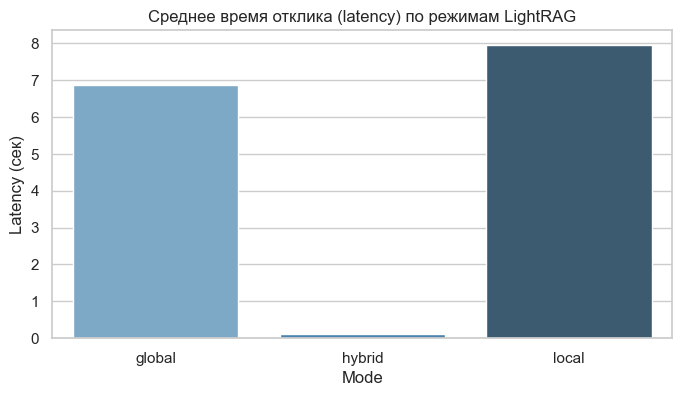

/var/folders/38/2h99w6rx1fz1qhgr17m1cbpm0000gn/T/ipykernel_84532/4252745491.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_df, x="mode", y="success", palette="Greens_d")


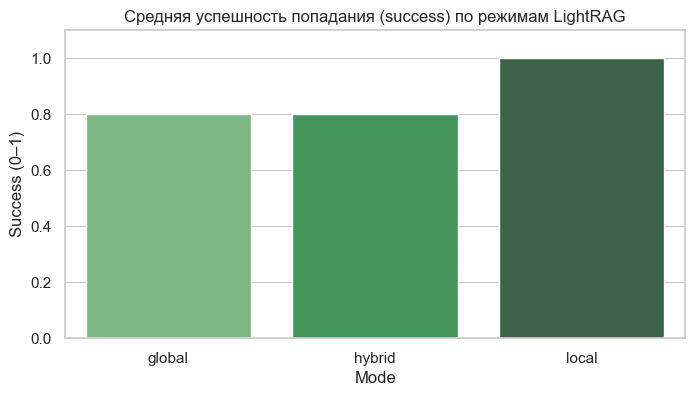

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set(style="whitegrid")

# Агрегация по mode
agg_df = combined.groupby("mode")[["latency", "success"]].mean().reset_index()

# График latency
plt.figure(figsize=(8,4))
sns.barplot(data=agg_df, x="mode", y="latency", palette="Blues_d")
plt.title("Среднее время отклика (latency) по режимам LightRAG")
plt.ylabel("Latency (сек)")
plt.xlabel("Mode")
plt.show()

# График success
plt.figure(figsize=(8,4))
sns.barplot(data=agg_df, x="mode", y="success", palette="Greens_d")
plt.title("Средняя успешность попадания (success) по режимам LightRAG")
plt.ylabel("Success (0–1)")
plt.xlabel("Mode")
plt.ylim(0, 1.1)
plt.show()


In [61]:
!pip install matplotlib seaborn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [54]:
import lightrag
import inspect
print(lightrag.__file__)


/Users/sergey/Projects/GigaSchool/llm-engineer/.venv/lib/python3.11/site-packages/lightrag/__init__.py


## Precision, Recall, F1 (proxy metrics)

На прямую мы не можем рассчитать метрики Precision, Recall, F1 так как  нет прямого доступа к “retrieved chunks” в  **LightRAG**, поэтому можно посчитать **proxy-метрики** через текст ответа (как мы делали с `hits` и `success`).



## 1️⃣ Определяем термины для нашей ситуации

* **True Positive (TP)** – ключевое слово/факт из ответа совпадает с эталонными ключевыми словами (reference/keywords).
* **False Positive (FP)** – слово/факт в ответе, которого нет в эталонном списке.
* **False Negative (FN)** – слово/факт из эталона, которого нет в ответе.

Тогда:

$$
\text{Precision} = \frac{TP}{TP + FP}, \quad
\text{Recall} = \frac{TP}{TP + FN}, \quad
\text{F1} = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

In [85]:
import re

def compute_precision_recall(answer: str, keywords: list[str]):
    """
    answer: текст, сгенерированный LightRAG
    keywords: список эталонных ключевых слов (reference)
    """
    answer_words = set(re.findall(r'\b\w+\b', answer.lower()))
    keywords_set = set(kw.lower() for kw in keywords)

    tp = len(answer_words & keywords_set)  # пересечение
    fp = len(answer_words - keywords_set)
    fn = len(keywords_set - answer_words)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return precision, recall, f1


In [72]:
metrics = []
for i, row in combined.iterrows():
    ans = row["answer"]
    keywords = eval_set[i % len(eval_set)]["keywords"]  # соответствие query → keywords
    p, r, f1 = compute_precision_recall(ans, keywords)
    metrics.append({"mode": row["mode"], "precision": p, "recall": r, "f1": f1})

metrics_df = pd.DataFrame(metrics)
print(metrics_df.groupby("mode")[["precision","recall","f1"]].mean())


        precision    recall        f1
mode                                 
global   0.018498  0.190476  0.033706
hybrid   0.019277  0.211905  0.035217
local    0.030496  0.328571  0.055323



| mode   | precision | recall | f1     |
| ------ | --------- | ------ | ------ |
| global | 0.0185    | 0.1905 | 0.0337 |
| hybrid | 0.0193    | 0.2119 | 0.0352 |
| local  | 0.0305    | 0.3286 | 0.0553 |


1. **Precision низкая (~0.02–0.03)**

   * LightRAG извлекает много “лишних слов” из текста, не относящихся к ключевым словам, поэтому точность маленькая.
   * Это типично для генеративного RAG: LLM возвращает текст, который может быть релевантным по смыслу, но не строго по ключевым словам.

2. **Recall выше (~0.19–0.33)**

   * Больше ключевых слов попадает в ответ, особенно в `local` режиме.
   * `local` на 33% покрывает нужные ключевые слова, `hybrid` ~21%, `global` ~19%.

3. **F1-score**

   * `local` режим выигрывает по F1, так как у него и recall выше, и чуть выше precision.
   * `hybrid` быстрее, но чуть хуже по полноте.

---

### Вывод

* **Если важна точность попадания ключевых слов и полнота** → используем `local`.
* **Если важна скорость и приемлемая полнота** → используем `hybrid`.
* `global` — компромисс, но по F1 отстаёт от `local`.

